In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_theme(style="whitegrid")

DATA_PATH = Path("/Users/ilyaklimasin/ecommerce_product_analytics/data")

orders = pd.read_csv(DATA_PATH / "olist_orders_dataset.csv")
customers = pd.read_csv(DATA_PATH / "olist_customers_dataset.csv")
order_items = pd.read_csv(
DATA_PATH / "olist_order_items_dataset.csv")
payments = pd.read_csv(DATA_PATH / "olist_order_payments_dataset.csv")
reviews = pd.read_csv(DATA_PATH / "olist_order_reviews_dataset.csv")

In [7]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for column in date_columns:
    orders[column] = pd.to_datetime(orders[column], errors="coerce")

items_by_order = order_items.groupby("order_id", as_index=False).agg(product_revenue=("price", "sum"), freight_value=("freight_value", "sum"), items_count=("order_item_id", "count"), sellers_count=("seller_id", "nunique"), products_count=("product_id", "nunique"))
items_by_order.head()

,order_id,product_revenue,freight_value,items_count,sellers_count,products_count
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,1,1,1
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,1,1,1
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,1,1,1
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,1,1,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,1,1,1


In [8]:
items_by_order["order_id"].nunique(), len(items_by_order)

(98666, 98666)

In [11]:
payments_by_order = (
    payments
    .groupby("order_id", as_index=False)
    .agg(
        payment_value=("payment_value", "sum"),
        payment_records=("payment_sequential", "count"),
        installments_max=("payment_installments", "max"),
        payment_types_count=("payment_type", "nunique"),
    )
)

payments_by_order.head()

,order_id,payment_value,payment_records,installments_max,payment_types_count
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,1,2,1
1,00018f77f2f0320c557190d7a144bdd3,259.83,1,3,1
2,000229ec398224ef6ca0657da4fc703e,216.87,1,5,1
3,00024acbcdf0a6daa1e931b038114c75,25.78,1,2,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,1,3,1


In [10]:
reviews_by_order = reviews.groupby("order_id", as_index=False).agg(review_score=("review_score", "mean"), reviews_count=("review_id", "count"),)
reviews_by_order.head()

,order_id,review_score,reviews_count
0,00010242fe8c5a6d1ba2dd792cb16214,5.00,1
1,00018f77f2f0320c557190d7a144bdd3,4.00,1
2,000229ec398224ef6ca0657da4fc703e,5.00,1
3,00024acbcdf0a6daa1e931b038114c75,4.00,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.00,1


In [13]:
order_dataset = orders.merge(customers, on="customer_id", how="left", validate="many_to_one").merge(items_by_order, on="order_id", how="left", validate="one_to_one").merge(payments_by_order, on="order_id", how="left", validate="one_to_one").merge(reviews_by_order, on="order_id", how="left", validate="one_to_one")
order_dataset.shape

(99441, 23)

In [14]:
order_dataset["order_id"].nunique(), len(order_dataset)

(99441, 99441)

In [16]:
order_dataset["purchase_month"] = order_dataset["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()
order_dataset["delivery_days"] = (order_dataset["order_delivered_customer_date"] - order_dataset["order_purchase_timestamp"]).dt.total_seconds()/86400
order_dataset["delay_days"] = (order_dataset["order_delivered_customer_date"] - order_dataset["order_estimated_delivery_date"]).dt.total_seconds()/86400
order_dataset["is_late"] = order_dataset["order_delivered_customer_date"] > order_dataset["order_estimated_delivery_date"]
order_dataset["is_canceled"] = order_dataset["order_status"] == "canceled"

In [17]:
delivered = order_dataset[order_dataset["order_status"] == "delivered"].copy()

In [18]:
delivered_orders_count = delivered["order_id"].nunique()
delivered_orders_count

96478

In [20]:
unique_customers = delivered["customer_unique_id"].nunique()
unique_customers

93358

In [22]:
total_product_revenue = delivered["product_revenue"].sum()
total_product_revenue

np.float64(13221498.110000001)

In [23]:
total_freight = delivered["freight_value"].sum()
total_freight

np.float64(2198275.6399999997)

In [24]:
average_order_value = delivered["product_revenue"].mean()
average_order_value

np.float64(137.04158575011922)

In [31]:
average_items_per_order= delivered["items_count"].mean()
average_items_per_order

np.float64(1.1421982213561641)

In [26]:
average_review_score = delivered["review_score"].mean()
average_review_score

np.float64(4.156186520855942)

In [27]:
average_delivery_days = delivered["delivery_days"].mean()
average_delivery_days

np.float64(12.558217098051975)

In [32]:
late_delivery_rate = delivered["is_late"].mean()
late_delivery_rate

np.float64(0.08111693857667032)

In [29]:
cancellation_rate = order_dataset["is_canceled"].mean()
cancellation_rate

np.float64(0.006285133898492574)

In [33]:
kpi_summary = pd.DataFrame({
    "metric": [
        "Delivered orders",
        "Unique customers",
        "Product revenue",
        "Freight value",
        "Average order value",
        "Average items per order",
        "Average review score",
        "Average delivery days",
        "Late delivery rate",
        "Cancellation rate",
    ],
    "value": [
        delivered_orders_count,
        unique_customers,
        total_product_revenue,
        total_freight,
        average_order_value,
        average_items_per_order,
        average_review_score,
        average_delivery_days,
        late_delivery_rate,
        cancellation_rate,
    ]
})

kpi_summary

,metric,value
0,Delivered orders,96478.00
1,Unique customers,93358.00
2,Product revenue,13221498.11
3,Freight value,2198275.64
4,Average order value,137.04
5,Average items per order,1.14
6,Average review score,4.16
7,Average delivery days,12.56
8,Late delivery rate,0.08
9,Cancellation rate,0.01


In [34]:
monthly_metrics = delivered.groupby("purchase_month", as_index=False).agg(
        orders_count=("order_id", "nunique"),
        unique_customers=("customer_unique_id", "nunique"),
        product_revenue=("product_revenue", "sum"),
        average_order_value=("product_revenue", "mean"),
        average_delivery_days=("delivery_days", "mean"),
        late_delivery_rate=("is_late", "mean"),
        average_review_score=("review_score", "mean"),
    )
monthly_metrics.head()

,purchase_month,orders_count,unique_customers,product_revenue,average_order_value,average_delivery_days,late_delivery_rate,average_review_score
0,2016-09-01,1,1,134.97,134.97,54.81,1.00,1.00
1,2016-10-01,265,262,40325.11,152.17,19.60,0.01,4.01
2,2016-12-01,1,1,10.90,10.90,4.69,0.00,5.00
3,2017-01-01,750,718,111798.36,149.06,12.65,0.03,4.20
4,2017-02-01,1653,1630,234223.40,141.70,13.17,0.03,4.20


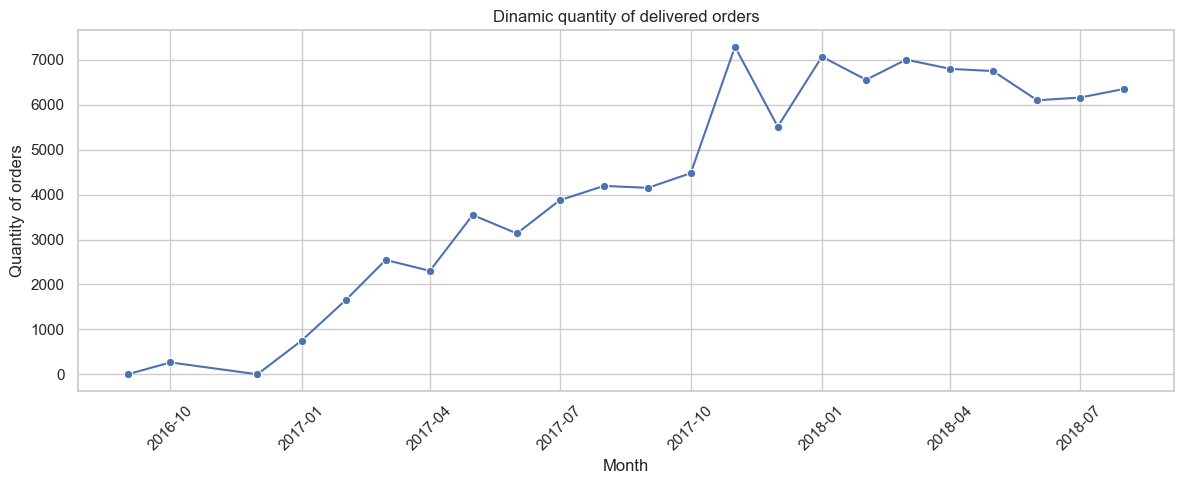

In [35]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_metrics, x="purchase_month", y="orders_count", marker="o")

plt.title("Dinamic quantity of delivered orders")
plt.xlabel("Month")
plt.ylabel("Quantity of orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

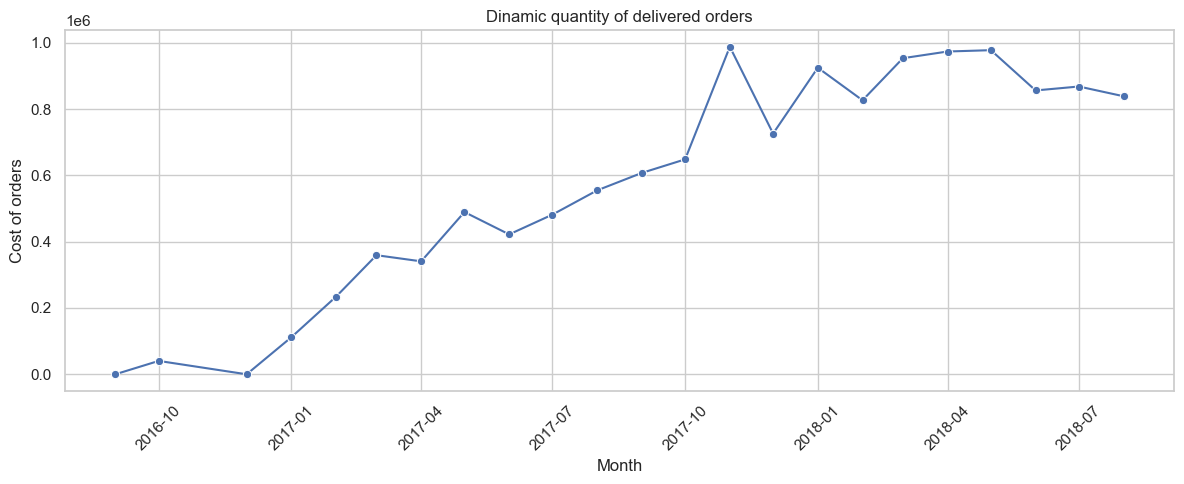

In [36]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_metrics,
    x="purchase_month",
    y="product_revenue",
    marker="o"
)

plt.title("Dinamic quantity of delivered orders")
plt.xlabel("Month")
plt.ylabel("Cost of orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [37]:
monthly_coverage = (
    orders
    .groupby(
        orders["order_purchase_timestamp"].dt.to_period("M")
    )["order_purchase_timestamp"]
    .agg(["min", "max", "count"])
)

monthly_coverage

,min,max,count
order_purchase_timestamp,,,
2016-09,2016-09-04 21:15:19,2016-09-15 12:16:38,4
2016-10,2016-10-02 22:07:52,2016-10-22 08:25:27,324
2016-12,2016-12-23 23:16:47,2016-12-23 23:16:47,1
2017-01,2017-01-05 11:56:06,2017-01-31 23:37:58,800
2017-02,2017-02-01 00:04:17,2017-02-28 23:47:08,1780
2017-03,2017-03-01 00:01:30,2017-03-31 23:54:45,2682
2017-04,2017-04-01 00:54:10,2017-04-30 23:48:13,2404
2017-05,2017-05-01 01:18:22,2017-05-31 22:59:52,3700
2017-06,2017-06-01 00:05:38,2017-06-30 23:20:08,3245


In [38]:
print("Строк в orders:", len(orders))
print("Строк в order_dataset:", len(order_dataset))
print(
    "Уникальных заказов:",
    order_dataset["order_id"].nunique()
)

Строк в orders: 99441
Строк в order_dataset: 99441
Уникальных заказов: 99441


In [39]:
financial_check = delivered[
    [
        "order_id",
        "product_revenue",
        "freight_value",
        "payment_value",
    ]
].copy()

financial_check["calculated_total"] = (
    financial_check["product_revenue"]
    + financial_check["freight_value"]
)

financial_check["payment_difference"] = (
    financial_check["payment_value"]
    - financial_check["calculated_total"]
)

financial_check[
    [
        "product_revenue",
        "freight_value",
        "payment_value",
        "payment_difference",
    ]
].describe()

,product_revenue,freight_value,payment_value,payment_difference
count,96478.00,96478.00,96477.00,96477.00
mean,137.04,22.79,159.86,0.03
std,209.05,21.56,218.81,1.14
min,0.85,0.00,9.59,-51.62
25%,45.90,13.85,61.88,0.00
50%,86.57,17.17,105.28,0.00
75%,149.90,24.02,176.33,0.00
max,13440.00,1794.96,13664.08,182.81


In [40]:
financial_mismatches = financial_check[
    financial_check["payment_difference"].abs() > 0.01
]

print(
    "Заказов с расхождением:",
    len(financial_mismatches)
)

print(
    "Доля заказов с расхождением:",
    f"{len(financial_mismatches) / len(financial_check):.2%}"
)

Заказов с расхождением: 375
Доля заказов с расхождением: 0.39%


In [41]:
monthly_coverage = monthly_coverage.reset_index()

monthly_coverage["days_in_data"] = (
    monthly_coverage["max"].dt.day
    - monthly_coverage["min"].dt.day
    + 1
)

monthly_coverage

,order_purchase_timestamp,min,max,count,days_in_data
0,2016-09,2016-09-04 21:15:19,2016-09-15 12:16:38,4,12
1,2016-10,2016-10-02 22:07:52,2016-10-22 08:25:27,324,21
2,2016-12,2016-12-23 23:16:47,2016-12-23 23:16:47,1,1
3,2017-01,2017-01-05 11:56:06,2017-01-31 23:37:58,800,27
4,2017-02,2017-02-01 00:04:17,2017-02-28 23:47:08,1780,28
5,2017-03,2017-03-01 00:01:30,2017-03-31 23:54:45,2682,31
6,2017-04,2017-04-01 00:54:10,2017-04-30 23:48:13,2404,30
7,2017-05,2017-05-01 01:18:22,2017-05-31 22:59:52,3700,31
8,2017-06,2017-06-01 00:05:38,2017-06-30 23:20:08,3245,30
9,2017-07,2017-07-01 00:04:15,2017-07-31 23:55:27,4026,31


In [42]:
monthly_coverage.head(3)

,order_purchase_timestamp,min,max,count,days_in_data
0,2016-09,2016-09-04 21:15:19,2016-09-15 12:16:38,4,12
1,2016-10,2016-10-02 22:07:52,2016-10-22 08:25:27,324,21
2,2016-12,2016-12-23 23:16:47,2016-12-23 23:16:47,1,1


In [43]:
monthly_coverage.tail(3)

,order_purchase_timestamp,min,max,count,days_in_data
22,2018-08,2018-08-01 00:02:17,2018-08-31 16:13:44,6512,31
23,2018-09,2018-09-03 09:06:57,2018-09-29 09:13:03,16,27
24,2018-10,2018-10-01 15:30:09,2018-10-17 17:30:18,4,17


In [44]:
full_month_metrics = monthly_metrics[
    (
        monthly_metrics["purchase_month"]
        > monthly_metrics["purchase_month"].min()
    )
    &
    (
        monthly_metrics["purchase_month"]
        < monthly_metrics["purchase_month"].max()
    )
].copy()

In [46]:
PROCESSED_PATH = Path("../data/processed")
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)
order_dataset.to_csv(
    PROCESSED_PATH / "orders_enriched.csv",
    index=False
)
monthly_metrics.to_csv(
    PROCESSED_PATH / "monthly_metrics.csv",
    index=False
)

In [47]:
order_dataset = pd.read_csv(
    "../data/processed/orders_enriched.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "purchase_month",
    ]
)

## Выводы второго этапа

1. Таблицы товаров, платежей и отзывов предварительно агрегированы до уровня заказа, что позволило избежать задвоения денежных показателей при объединении.

2. Сформирован аналитический датасет, содержащий одну строку на один заказ. После объединения в таблице осталось 99 441 строка и 99 441 уникальный `order_id`.

3. Для завершённых заказов рассчитаны основные бизнес-показатели:
   - количество доставленных заказов — 96478;
   - количество уникальных клиентов — 93358;
   - стоимость проданных товаров — 13.22 млн;
   - средний чек — 136.98;
   - среднее количество товаров в заказе — 1.14;
   - средний срок доставки — 12.56 дней;
   - доля задержанных доставок — 8.1%;
   - средняя оценка заказа — 4.16;
   - доля отменённых заказов — 0.63%.

4. Построена месячная динамика количества заказов и стоимости проданных товаров.

5. Первый и последний месяцы периода содержат неполные данные, поэтому они не должны использоваться для прямого сравнения с полными календарными месяцами.

6. Подготовленная таблица сохранена в `data/processed/orders_enriched.csv` для использования на следующих этапах.

7. Следующий этап посвящён когортному анализу и исследованию повторных покупок клиентов.